COMPREHENSIVE SEASONAL ANALYSIS (Conventional + Typhoon-Specific)

Calculating conventional seasonal performance...
Calculating typhoon-specific period performance...

CONVENTIONAL SEASONAL STATISTICS

Spring (3-5):
  Model         NSE     RMSE (m³/s)
  -----------------------------------
  LR          0.892          178.97
  ANN         0.907          166.39
  RF          0.814          235.48
  XGB         0.896          176.25

Summer (6-8):
  Model         NSE     RMSE (m³/s)
  -----------------------------------
  LR          0.925          320.25
  ANN         0.944          276.34
  RF          0.672          671.37
  XGB         0.868          425.96

Autumn (9-11):
  Model         NSE     RMSE (m³/s)
  -----------------------------------
  LR          0.844          127.05
  ANN         0.866          118.10
  RF          0.800          143.96
  XGB         0.853          123.60

Winter (12-2):
  Model         NSE     RMSE (m³/s)
  -----------------------------------
  LR     

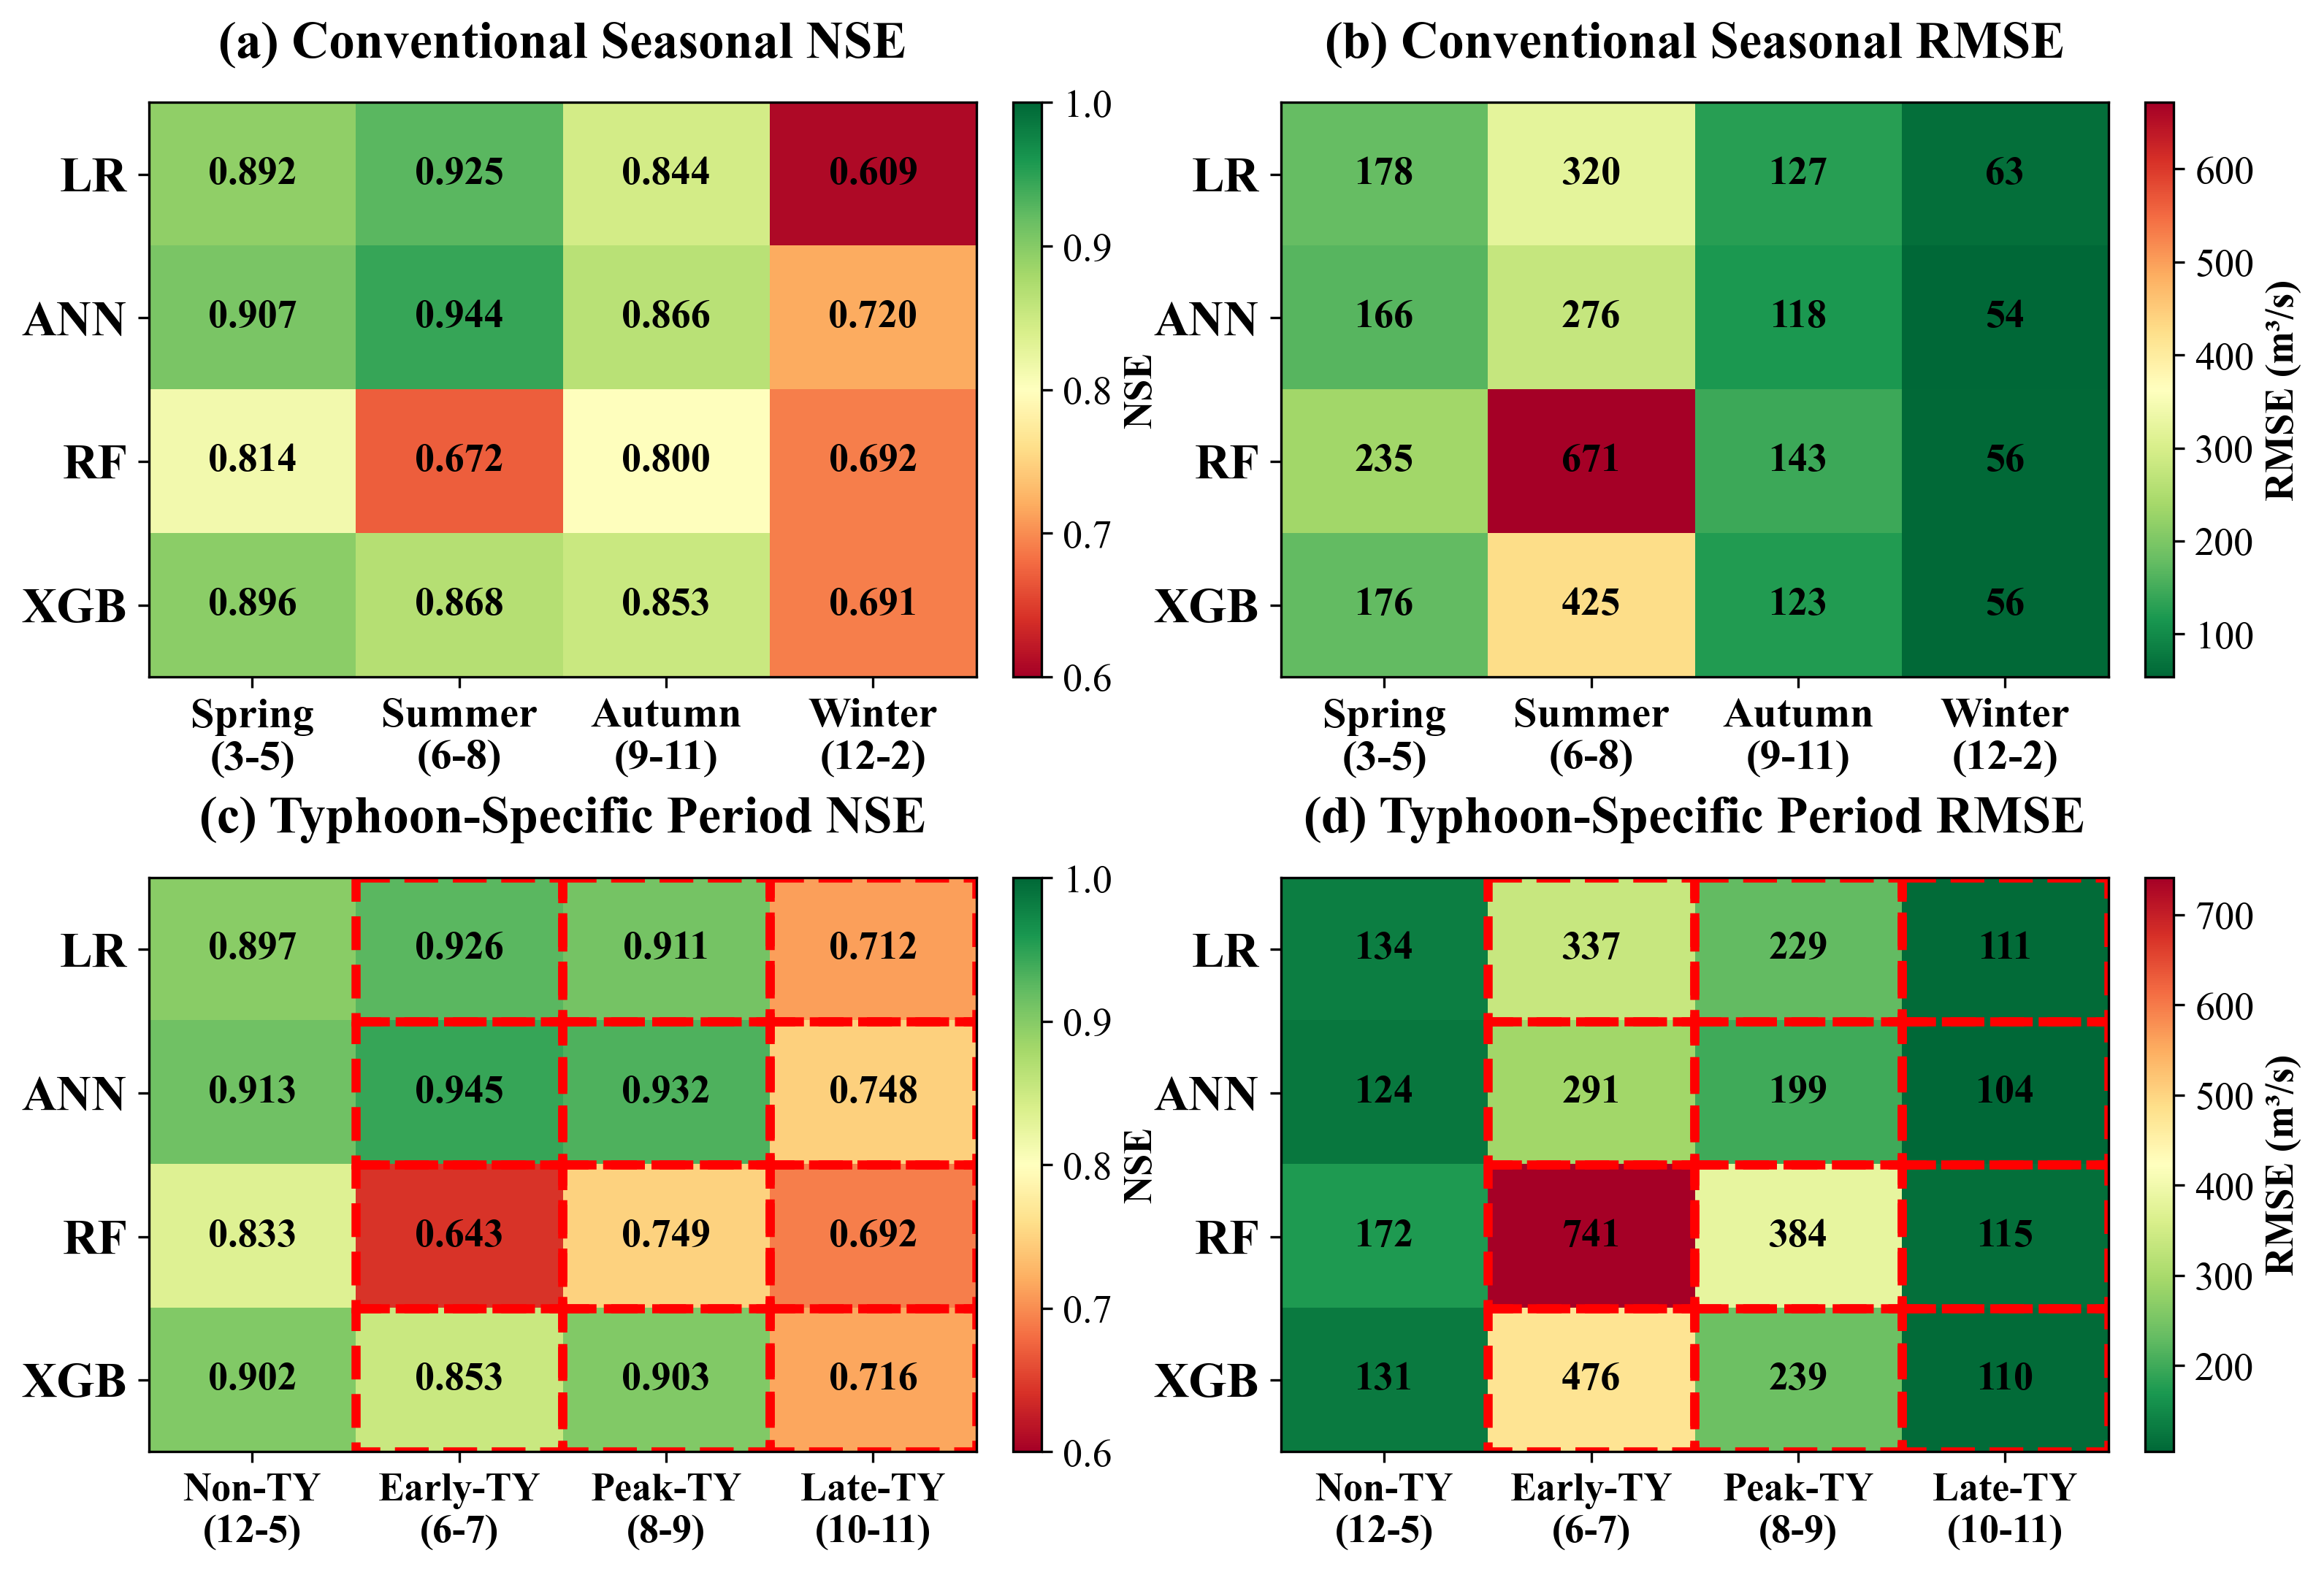


✓ ANALYSIS COMPLETE!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from math import pi

# Set font to Times New Roman
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 14

def calculate_conventional_seasonal_performance(results_dir='predictions'):
    """
    Calculate conventional four-season performance
    """
    models = ['LR', 'ANN', 'RF', 'XGB']
    seasons = ['Spring\n(3-5)', 'Summer\n(6-8)', 
               'Autumn\n(9-11)', 'Winter\n(12-2)']
    
    seasonal_nse = {}
    seasonal_rmse = {}
    
    for model in models:
        pred_file = f'{results_dir}/with_typhoon_enhanced_{model}_predictions.csv'
        pred_df = pd.read_csv(pred_file)
        
        pred_df['date'] = pd.to_datetime(pred_df['date'])
        pred_df['month'] = pred_df['date'].dt.month
        
        def get_season(month):
            if month in [3, 4, 5]:
                return 'Spring\n(3-5)'
            elif month in [6, 7, 8]:
                return 'Summer\n(6-8)'
            elif month in [9, 10, 11]:
                return 'Autumn\n(9-11)'
            else:
                return 'Winter\n(12-2)'
        
        pred_df['season'] = pred_df['month'].apply(get_season)
        
        model_seasonal_nse = []
        model_seasonal_rmse = []
        
        for season in seasons:
            season_data = pred_df[pred_df['season'] == season]
            obs = season_data['observed'].values
            pred = season_data['predicted'].values
            
            nse_val = 1 - np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2)
            model_seasonal_nse.append(nse_val)
            
            rmse_val = np.sqrt(np.mean((obs - pred)**2))
            model_seasonal_rmse.append(rmse_val)
        
        seasonal_nse[model] = model_seasonal_nse
        seasonal_rmse[model] = model_seasonal_rmse
    
    return seasonal_nse, seasonal_rmse, seasons

def calculate_typhoon_seasonal_performance(results_dir='predictions'):
    """
    Calculate model performance during typhoon-specific periods:
    - Non-typhoon: Jan-May + Dec (6 months total)
    - Early typhoon: Jun-Jul (2 months)
    - Peak typhoon: Aug-Sep (2 months)
    - Late typhoon: Oct-Nov (2 months)
    """
    models = ['LR', 'ANN', 'RF', 'XGB']
    
    # Define typhoon-specific periods (合并12月到无台风时段)
    periods = ['Non-Typhoon\n(12-5)', 'Early Typhoon\n(6-7)', 
               'Peak Typhoon\n(8-9)', 'Late Typhoon\n(10-11)']
    
    def get_typhoon_period(month):
        if month in [1, 2, 3, 4, 5, 12]:  # 合并12月到无台风时段
            return 'Non-Typhoon\n(12-5)'
        elif month in [6, 7]:
            return 'Early Typhoon\n(6-7)'
        elif month in [8, 9]:
            return 'Peak Typhoon\n(8-9)'
        elif month in [10, 11]:
            return 'Late Typhoon\n(10-11)'
    
    period_nse = {}
    period_rmse = {}
    period_samples = {}
    
    for model in models:
        pred_file = f'{results_dir}/with_typhoon_enhanced_{model}_predictions.csv'
        pred_df = pd.read_csv(pred_file)
        
        # Convert date
        pred_df['date'] = pd.to_datetime(pred_df['date'])
        pred_df['month'] = pred_df['date'].dt.month
        pred_df['period'] = pred_df['month'].apply(get_typhoon_period)
        
        # Calculate metrics for each period
        model_nse = []
        model_rmse = []
        model_samples = []
        
        for period in periods:
            period_data = pred_df[pred_df['period'] == period]
            obs = period_data['observed'].values
            pred = period_data['predicted'].values
            
            # NSE
            nse_val = 1 - np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2)
            model_nse.append(nse_val)
            
            # RMSE
            rmse_val = np.sqrt(np.mean((obs - pred)**2))
            model_rmse.append(rmse_val)
            
            # Sample count
            model_samples.append(len(period_data))
        
        period_nse[model] = model_nse
        period_rmse[model] = model_rmse
        period_samples[model] = model_samples
    
    return period_nse, period_rmse, period_samples, periods

def plot_combined_seasonal_heatmap(seasonal_nse, seasonal_rmse, seasons,
                                   period_nse, period_rmse, periods,
                                   output_file='results_v3/Figure3_seasonal_analysis.png',
                                   figsize=(12, 8), dpi=300):
    """
    绘制热力图展示传统4季节和台风特定时段的表现对比
    """
    models = list(seasonal_nse.keys())
    
    # 创建2x2子图布局
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)
    
    # 准备数据
    nse_data = np.array([seasonal_nse[model] for model in models])
    rmse_data = np.array([seasonal_rmse[model] for model in models])
    
    period_nse_data = np.array([period_nse[model] for model in models])
    period_rmse_data = np.array([period_rmse[model] for model in models])

    # ========== (a) 传统季节NSE热力图 ==========
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(nse_data, cmap='RdYlGn', aspect='auto', vmin=0.6, vmax=1.0)
    
    # 设置刻度
    season_labels = [s.replace('\n', ' ') for s in seasons]
    ax1.set_xticks(np.arange(len(seasons)))
    ax1.set_yticks(np.arange(len(models)))
    season_labels = ['Spring\n(3-5)', 'Summer\n(6-8)', 
               'Autumn\n(9-11)', 'Winter\n(12-2)']
    ax1.set_xticklabels(season_labels, fontsize=14, fontweight='bold')
    ax1.set_yticklabels(models, fontsize=16, fontweight='bold')
    
    # 添加数值标签
    for i in range(len(models)):
        for j in range(len(seasons)):
            text = ax1.text(j, i, f'{nse_data[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=13, fontweight='bold')
    
    ax1.set_title('(a) Conventional Seasonal NSE', fontsize=17, fontweight='bold', pad=15)
    # ax1.set_xlabel('Season', fontsize=15, fontweight='bold')
    # ax1.set_ylabel('Model', fontsize=15, fontweight='bold')
    
    # 添加颜色条
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('NSE', fontsize=13, weight='bold')
    cbar1.ax.tick_params(labelsize=13)
    
    # ========== (b) 传统季节RMSE热力图 ==========
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(rmse_data, cmap='RdYlGn_r', aspect='auto')
    
    ax2.set_xticks(np.arange(len(seasons)))
    ax2.set_yticks(np.arange(len(models)))
    ax2.set_xticklabels(season_labels, fontsize=14, fontweight='bold')
    ax2.set_yticklabels(models, fontsize=16, fontweight='bold')
    
    # 添加数值标签
    for i in range(len(models)):
        for j in range(len(seasons)):
            text = ax2.text(j, i, f'{int(rmse_data[i, j])}',
                          ha="center", va="center", color="black", fontsize=13, fontweight='bold')
    
    ax2.set_title('(b) Conventional Seasonal RMSE', fontsize=17, fontweight='bold', pad=15)
    # ax2.set_xlabel('Season', fontsize=15, fontweight='bold')
    # ax2.set_ylabel('Model', fontsize=15, fontweight='bold')
    
    cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.set_label('RMSE (m³/s)', fontsize=13, weight='bold')
    cbar2.ax.tick_params(labelsize=13)
    
    # ========== (c) 台风特定时段NSE热力图 ==========
    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.imshow(period_nse_data, cmap='RdYlGn', aspect='auto', vmin=0.6, vmax=1.0)
    
    # 简化标签
    period_labels = ['Non-TY\n(12-5)', 'Early-TY\n(6-7)', 'Peak-TY\n(8-9)', 
                     'Late-TY\n(10-11)']
    
    ax3.set_xticks(np.arange(len(periods)))
    ax3.set_yticks(np.arange(len(models)))
    ax3.set_xticklabels(period_labels, fontsize=13, fontweight='bold')
    ax3.set_yticklabels(models, fontsize=16, fontweight='bold')
    
    # 添加数值标签
    for i in range(len(models)):
        for j in range(len(periods)):
            text = ax3.text(j, i, f'{period_nse_data[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=13, fontweight='bold')
    
    ax3.set_title('(c) Typhoon-Specific Period NSE', fontsize=17, fontweight='bold', pad=15)
    # ax3.set_xlabel('Typhoon Period', fontsize=15, fontweight='bold')
    # ax3.set_ylabel('Model', fontsize=15, fontweight='bold')
    
    # 高亮台风季节（索引1-3: Early, Peak, Late）
    for ty_idx in [1, 2, 3]:
        for i in range(len(models)):
            rect = plt.Rectangle((ty_idx-0.5, i-0.5), 1, 1, 
                               fill=False, edgecolor='red', linewidth=3, linestyle='--')
            ax3.add_patch(rect)
    
    cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    cbar3.set_label('NSE', fontsize=13, weight='bold')
    cbar3.ax.tick_params(labelsize=13)
    
    # ========== (d) 台风特定时段RMSE热力图 ==========
    ax4 = fig.add_subplot(gs[1, 1])
    im4 = ax4.imshow(period_rmse_data, cmap='RdYlGn_r', aspect='auto')
    
    ax4.set_xticks(np.arange(len(periods)))
    ax4.set_yticks(np.arange(len(models)))
    ax4.set_xticklabels(period_labels, fontsize=13, fontweight='bold')
    ax4.set_yticklabels(models, fontsize=16, fontweight='bold')
    
    # 添加数值标签
    for i in range(len(models)):
        for j in range(len(periods)):
            text = ax4.text(j, i, f'{int(period_rmse_data[i, j])}',
                          ha="center", va="center", color="black", fontsize=13, fontweight='bold')
    
    ax4.set_title('(d) Typhoon-Specific Period RMSE', fontsize=17, fontweight='bold', pad=15)
    # ax4.set_xlabel('Typhoon Period', fontsize=15, fontweight='bold')
    # ax4.set_ylabel('Model', fontsize=15, fontweight='bold')
    
    # 高亮台风季节
    for ty_idx in [1, 2, 3]:
        for i in range(len(models)):
            rect = plt.Rectangle((ty_idx-0.5, i-0.5), 1, 1, 
                               fill=False, edgecolor='red', linewidth=3, linestyle='--')
            ax4.add_patch(rect)
    
    cbar4 = plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    cbar4.set_label('RMSE (m³/s)', fontsize=13, weight='bold')
    cbar4.ax.tick_params(labelsize=13)
    
    # 保存图像
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', pad_inches=0.3)
    print(f"✓ Combined seasonal heatmap saved to: {output_file}")
    
    plt.show()

def print_statistics(seasonal_nse, seasonal_rmse, seasons,
                    period_nse, period_rmse, period_samples, periods):
    """
    Print detailed statistics for both analyses
    """
    models = list(seasonal_nse.keys())
    
    print("\n" + "="*100)
    print("CONVENTIONAL SEASONAL STATISTICS")
    print("="*100)
    for i, season in enumerate(seasons):
        season_clean = season.replace('\n', ' ')
        print(f"\n{season_clean}:")
        print(f"  {'Model':<8} {'NSE':>8} {'RMSE (m³/s)':>15}")
        print(f"  {'-'*35}")
        for model in models:
            print(f"  {model:<8} {seasonal_nse[model][i]:>8.3f} {seasonal_rmse[model][i]:>15.2f}")
    
    print("\n" + "="*100)
    print("TYPHOON-SPECIFIC PERIOD STATISTICS")
    print("="*100)
    for i, period in enumerate(periods):
        period_clean = period.replace('\n', ' ')
        print(f"\n{period_clean}:")
        print(f"  Samples: {period_samples['LR'][i]}")
        print(f"  {'Model':<8} {'NSE':>8} {'RMSE (m³/s)':>15}")
        print(f"  {'-'*35}")
        for model in models:
            nse = period_nse[model][i]
            rmse = period_rmse[model][i]
            print(f"  {model:<8} {nse:>8.3f} {rmse:>15.2f}")
    
    # Performance comparison
    print("\n" + "="*100)
    print("COMPARISON: Peak Typhoon Period vs Non-Typhoon Period")
    print("="*100)
    
    peak_idx = 2  # Peak typhoon (Aug-Sep)
    non_ty_idx = 0  # Non-typhoon (1-5, 12)
    
    print(f"\n{'Model':<8} {'NSE Diff':>12} {'RMSE Diff':>15} {'RMSE Change %':>18}")
    print(f"{'-'*60}")
    
    for model in models:
        nse_diff = period_nse[model][peak_idx] - period_nse[model][non_ty_idx]
        rmse_diff = period_rmse[model][peak_idx] - period_rmse[model][non_ty_idx]
        rmse_pct = (rmse_diff / period_rmse[model][non_ty_idx]) * 100
        
        print(f"{model:<8} {nse_diff:>12.3f} {rmse_diff:>15.2f} {rmse_pct:>17.1f}%")

if __name__ == "__main__":
    print("="*100)
    print("COMPREHENSIVE SEASONAL ANALYSIS (Conventional + Typhoon-Specific)")
    print("="*100)
    
    # Calculate conventional seasonal performance
    print("\nCalculating conventional seasonal performance...")
    seasonal_nse, seasonal_rmse, seasons = calculate_conventional_seasonal_performance()
    
    # Calculate typhoon-specific period performance
    print("Calculating typhoon-specific period performance...")
    period_nse, period_rmse, period_samples, periods = calculate_typhoon_seasonal_performance()
    
    # Print statistics
    print_statistics(seasonal_nse, seasonal_rmse, seasons,
                    period_nse, period_rmse, period_samples, periods)
    
    # Generate combined heatmap
    print("\nGenerating combined seasonal heatmap...")
    plot_combined_seasonal_heatmap(seasonal_nse, seasonal_rmse, seasons,
                                   period_nse, period_rmse, periods)
    
    print("\n" + "="*100)
    print("✓ ANALYSIS COMPLETE!")
    print("="*100)